# Predição de Capacidade de Armazenamento (*Capacity Planning*) com Regressão Linear Simples

**Iniciação Científica** — *Introdução aos Paradigmas de Machine Learning por meio do Estudo,
Implementação e Avaliação de Algoritmos Clássicos*

- **Aluno:** Maurício Jampani de Souza
- **Orientador:** Prof. Me. Marcio Rodrigues Sabino
- **Dataset:** `monitoramento_disco_10k_v2.csv` — 10.000 observações diárias
- **Área:** Análise e Desenvolvimento de Sistemas / Infraestrutura de TI

---

## Estrutura

| Etapa | Conteúdo |
|---|---|
| **1** | Análise exploratória: descritivas, integridade, natureza das variáveis, *overplotting* |
| **2** | Ajuste por mínimos quadrados — dedução, implementação manual e comparação com `scikit-learn` |
| **3** | Avaliação: decomposição da variância, $R^2$, RMSE, análise de resíduos |
| **4** | Predição do esgotamento e recomendação técnica |

## O que este relatório acrescenta ao enunciado

Três análises não pedidas explicitamente, mas que mudam a conclusão operacional:

1. **Detecção de censura (piso artificial)** nos dados e seu efeito sobre as hipóteses do modelo.
2. **Análise de resíduos** — o enunciado nomeia a Etapa 3 como "Avaliação do Ajuste **e Resíduos**"
   mas só pede $R^2$ e RMSE.
3. **Intervalo de predição vs. intervalo de confiança** — a diferença entre prever a *média* e
   prever *um dia concreto*. É o que separa uma resposta algébrica de uma recomendação de
   *capacity planning* utilizável.

---
# 0. Configuração

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Reprodutibilidade: toda amostragem deste notebook usa esta semente.
SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.5.3 | pandas 3.0.6


In [2]:
# Carregamento do CSV.
# Local: o arquivo está ao lado do notebook.
# Google Colab: abre o seletor de upload na primeira execução.
from pathlib import Path

ARQUIVO = "monitoramento_disco_10k_v2.csv"

if not Path(ARQUIVO).exists():
    try:
        from google.colab import files  # type: ignore
        print(f"Selecione o arquivo {ARQUIVO} para upload:")
        files.upload()
    except ImportError:
        raise FileNotFoundError(
            f"{ARQUIVO} não encontrado. Coloque-o na mesma pasta do notebook."
        )

df = pd.read_csv(ARQUIVO)
df.head()

,dia,uso_disco_gb
0,1,233.9300
1,2,89.3100
2,3,269.3200
3,4,469.7400
4,5,68.7600


---
# Etapa 1 — Análise Exploratória de Dados

## 1.0 Natureza das variáveis

Antes de calcular qualquer estatística, é preciso saber **o que cada coluna é**, porque isso
determina quais operações fazem sentido.

| Variável | Tipo | Escala | Zero |
|---|---|---|---|
| `dia` | quantitativa **discreta** | **intervalar** | arbitrário (início do monitoramento) |
| `uso_disco_gb` | quantitativa **contínua** | **de razão** | absoluto (disco vazio) |

Consequências práticas:

- Em `dia`, "o dia 200 é o dobro do dia 100" **não** é uma frase válida — o zero é convenção.
  Em `uso_disco_gb`, "200 GB é o dobro de 100 GB" **é** válida.
- `dia` é uma sequência $1, 2, \ldots, n$ **escolhida**, não medida. No modelo clássico
  $y = \beta_0 + \beta_1 x + \varepsilon$, a variável $x$ é tratada como **fixa e conhecida sem
  erro**; toda a aleatoriedade reside em $\varepsilon$. Portanto, média e desvio padrão de `dia`
  não descrevem o servidor — descrevem o formato do dataset.
- Isso **não** os torna inúteis: $\bar{x}$ e $S_{xx} = \sum (x_i - \bar{x})^2$ são a geometria do
  desenho amostral e aparecem literalmente nas fórmulas das Etapas 2 e 4.

**Ponto crítico de leitura:** `uso_disco_gb` é a **ocupação total acumulada** do disco, não o
consumo daquele dia. É isso que dá sentido à pergunta "quando a ocupação atinge 5.000 GB?".

In [3]:
# --- Integridade: o dataset é o que o enunciado promete? ---------------------
# `assert` aborta a execução se a condição for falsa. Em análise de dados isso é
# preferível a um `if`: se a premissa não vale, nenhum resultado adiante vale.

print("dimensões (linhas, colunas):", df.shape)
print("colunas:", list(df.columns))
print("tipos:", dict(df.dtypes.astype(str)))
print("valores faltantes:", int(df.isna().sum().sum()))

assert df.shape == (10000, 2), f"esperava (10000, 2), veio {df.shape}"
assert list(df.columns) == ["dia", "uso_disco_gb"]
assert df.isna().sum().sum() == 0, "há valores faltantes"

# A Etapa 2 assume x = 1..n sem lacuna e sem repetição.
assert np.array_equal(df["dia"].values, np.arange(1, len(df) + 1)), "`dia` não é 1..n"

print("\n>>> Dataset íntegro: 10.000 dias consecutivos, sem lacunas.")

dimensões (linhas, colunas): (10000, 2)
colunas: ['dia', 'uso_disco_gb']
tipos: {'dia': 'int64', 'uso_disco_gb': 'float64'}
valores faltantes: 0

>>> Dataset íntegro: 10.000 dias consecutivos, sem lacunas.


## 1.1 Estatísticas descritivas

O enunciado pede média, desvio padrão, mínimo, mediana e máximo **das duas variáveis**. As duas
tabelas são apresentadas separadamente porque têm **estatuto epistemológico diferente**, e
juntá-las numa só induz a erro:

- Para `uso_disco_gb`, essas estatísticas são **medições**: resumem um fenômeno observado e
  poderiam ter dado qualquer outra coisa.
- Para `dia`, são **consequências aritméticas do desenho amostral**. A série é
  $1, 2, \ldots, n$ por construção; todas as cinco quantidades são deriváveis de $n$ sozinho,
  **sem abrir o arquivo**. Dizer "a média de `dia` é 5.000,5" não informa nada sobre o servidor —
  informa que o dataset tem 10.000 linhas sequenciais, o que já sabíamos.

A tabela de `dia` é portanto apresentada ao lado de suas formas fechadas. Ela **não é descrição:
é verificação de integridade** — se algum valor divergisse da fórmula, haveria lacuna, repetição
ou desordem na série.

In [4]:
# --- A tabela que carrega informação -----------------------------------------
descritivas = (
    df[["uso_disco_gb"]].describe()
    .loc[["mean", "std", "min", "50%", "max"]]
    .rename(index={
        "mean": "Média",
        "std": "Desvio padrão",
        "min": "Mínimo",
        "50%": "Mediana",
        "max": "Máximo",
    })
)
print("Estatísticas descritivas — uso_disco_gb (GB)")
display(descritivas.round(2))

Estatísticas descritivas — uso_disco_gb (GB)


,uso_disco_gb
Média,"2,370.8300"
Desvio padrão,"1,314.9000"
Mínimo,10.0000
Mediana,"2,361.6300"
Máximo,"5,109.2100"


In [5]:
# --- A tabela de `dia`: observado vs. previsto pela forma fechada -------------
# Cada linha mostra que o valor é determinado por n, não pelos dados.
n = len(df)

dia_conferencia = pd.DataFrame({
    "Observado": [
        df["dia"].mean(), df["dia"].std(), df["dia"].min(),
        df["dia"].median(), df["dia"].max(),
    ],
    "Forma fechada": [
        (n + 1) / 2,
        np.sqrt((n**2 - 1) / 12 * n / (n - 1)),
        1,
        (n + 1) / 2,
        n,
    ],
    "Expressão": [
        "(n+1)/2", "√[ (n²−1)/12 · n/(n−1) ]", "1", "(n+1)/2", "n",
    ],
}, index=["Média", "Desvio padrão", "Mínimo", "Mediana", "Máximo"])

print("`dia` — determinada pelo desenho, não pelos dados")
display(dia_conferencia.round(4))

# Se QUALQUER linha divergir, a série tem lacuna, repetição ou está fora de ordem.
assert np.allclose(dia_conferencia["Observado"], dia_conferencia["Forma fechada"])
print(">>> Todas as cinco coincidem: `dia` é exatamente 1..n. Integridade confirmada.")

`dia` — determinada pelo desenho, não pelos dados


,Observado,Forma fechada,Expressão
Média,"5,000.5000","5,000.5000",(n+1)/2
Desvio padrão,"2,886.8957","2,886.8957",√[ (n²−1)/12 · n/(n−1) ]
Mínimo,1.0000,1.0000,1
Mediana,"5,000.5000","5,000.5000",(n+1)/2
Máximo,"10,000.0000","10,000.0000",n


>>> Todas as cinco coincidem: `dia` é exatamente 1..n. Integridade confirmada.


Note que **média e mediana de `dia` são o mesmo número** — $(n+1)/2$ — e o mínimo e o máximo são
literalmente $1$ e $n$. Nenhuma dessas quantidades poderia ter dado outra coisa. Elas serão
usadas adiante, mas com outro papel: $\bar{x}$ e
$S_{xx} = \sum(x_i - \bar{x})^2$ entram nas fórmulas das Etapas 2 e 4 como **geometria do
desenho amostral**, não como descrição do servidor.

### Por que o desvio padrão de `dia` tem forma fechada

Como `dia` é a sequência determinística $1, 2, \ldots, n$, seu desvio padrão pode ser obtido
**sem olhar o arquivo**. Partindo de

$$\sum_{i=1}^{n} i = \frac{n(n+1)}{2} \quad\Longrightarrow\quad \bar{x} = \frac{n+1}{2},
\qquad \sum_{i=1}^{n} i^2 = \frac{n(n+1)(2n+1)}{6}$$

e usando $\operatorname{Var}_{\text{pop}} = \dfrac{\sum i^2}{n} - \bar{x}^2$:

$$\operatorname{Var}_{\text{pop}} = \frac{(n+1)(2n+1)}{6} - \frac{(n+1)^2}{4}
= \frac{(n+1)\left[2(2n+1) - 3(n+1)\right]}{12}
= \frac{(n+1)(n-1)}{12} = \boxed{\frac{n^2-1}{12}}$$

O `pandas` usa `ddof=1` (estimador **amostral**, divide por $n-1$), enquanto a fórmula acima é
**populacional** (divide por $n$). O fator de conversão é $\frac{n}{n-1}$.

> A mesma lógica de "graus de liberdade gastos" reaparece na Etapa 3, ali na forma de $n-2$.

In [6]:
var_pop = (n**2 - 1) / 12          # forma fechada, populacional
var_amostral = var_pop * n / (n - 1)

desvio_formula = np.sqrt(var_amostral)
desvio_pandas = df["dia"].std()

print(f"fórmula fechada : {desvio_formula:.12f}")
print(f"pandas (ddof=1) : {desvio_pandas:.12f}")
assert np.isclose(desvio_formula, desvio_pandas), "não bateu"
print("\n>>> CHECKPOINT 1 OK — o desvio de `dia` é previsível só a partir de n.")
print("    Confirma numericamente que `dia` é índice, não medição.")

fórmula fechada : 2886.895679907168
pandas (ddof=1) : 2886.895679907168

>>> CHECKPOINT 1 OK — o desvio de `dia` é previsível só a partir de n.
    Confirma numericamente que `dia` é índice, não medição.


### Leitura crítica de `uso_disco_gb`

- **Média ≈ mediana** → distribuição aproximadamente simétrica, sem assimetria grosseira.
- **Desvio padrão ≈ 1.315 GB** → ⚠️ **este número não é o ruído diário.** Como $y$ cresce ao
  longo da série, o desvio em torno da média $\bar{y}$ (uma reta *horizontal*) é dominado pela
  **inclinação** da nuvem, não pela sua **espessura**. O ruído diário só pode ser medido depois
  de ajustar a reta — é o desvio dos **resíduos** (Etapa 3).
  Mesma fórmula, referência diferente: $\sum(y_i - \bar y)^2$ mede distância até a horizontal,
  $\sum(y_i - \hat y_i)^2$ mede distância até a reta inclinada. Isso é exatamente
  $\mathrm{SQT}$ vs. $\mathrm{SQE}$.
- **Máximo = 5.109,21 GB** → já ultrapassa o limite operacional de 5.000 GB **dentro do período
  medido**. Investigado abaixo.
- **Mínimo = 10,00 GB** → valor suspeitosamente redondo. Investigado abaixo.

In [7]:
y_serie = df["uso_disco_gb"]

print("=== Extremos ===")
print(f"mínimo: dia {int(df.loc[y_serie.idxmin(), 'dia'])}, "
      f"y = {y_serie.min():.2f} GB")
print(f"máximo: dia {int(df.loc[y_serie.idxmax(), 'dia'])}, "
      f"y = {y_serie.max():.2f} GB")

# --- Censura (piso artificial) -----------------------------------------------
# Um valor contínuo que se repete EXATAMENTE não é ruído: é corte.
no_piso = (y_serie == y_serie.min())
print(f"\nlinhas com y exatamente == {y_serie.min():.2f}: {no_piso.sum()}")
print(f"ocorrem entre os dias {df.loc[no_piso, 'dia'].min()} e {df.loc[no_piso, 'dia'].max()}")

# --- Dias que já estouraram o limite operacional ------------------------------
LIMITE_GB = 5000
acima = y_serie > LIMITE_GB
print(f"\ndias com y > {LIMITE_GB} GB: {acima.sum()}")
if acima.any():
    print(f"primeiro: dia {df.loc[acima, 'dia'].min()} | "
          f"último: dia {df.loc[acima, 'dia'].max()}")

=== Extremos ===
mínimo: dia 14, y = 10.00 GB
máximo: dia 9908, y = 5109.21 GB

linhas com y exatamente == 10.00: 101
ocorrem entre os dias 14 e 1102

dias com y > 5000 GB: 9
primeiro: dia 9628 | último: dia 9944


### Duas descobertas que o enunciado não antecipa

**1. Os dados são censurados à esquerda (piso artificial em 10 GB).**
O valor 10,00 GB se repete **101 vezes**, exatamente, entre os dias 14 e 1.102. Uma variável
contínua com ruído não repete o mesmo valor com duas casas decimais uma centena de vezes — isso é
**corte**. A explicação: nos primeiros dias a tendência ainda é pequena e o ruído puxaria $y$
para valores negativos; como ocupação negativa não existe fisicamente, os valores foram truncados.

*Consequência estatística (relevante para a Etapa 3):* na região censurada, o erro
$\varepsilon_i$ **não pode** assumir os valores negativos que assumiria naturalmente. Ali os
resíduos deixam de ser simétricos e de ter média zero, violando uma hipótese do modelo clássico.
Isso será visível no gráfico de resíduos e será quantificado por uma análise de sensibilidade
na Etapa 2.

**2. O limite operacional já foi ultrapassado dentro da amostra.**
Nove dias registraram ocupação acima de 5.000 GB, o primeiro deles no dia 9.628 — todos
concentrados no fim da série. A *tendência média* ainda não atingiu o limite, mas as
**observações individuais** oscilam em torno dela e algumas já cruzaram. Esse é o argumento
central da Etapa 4.

## 1.2 Gráfico de dispersão — e o problema do *overplotting*

Com $n = 10{,}000$ pontos, um *scatter* ingênuo satura: na região densa cada marcador cobre o
vizinho e a informação de **densidade** desaparece. Isso é um problema de honestidade da
figura, não de estética. Abaixo, quatro representações do **mesmo dado**, com o que cada uma
revela e o que cada uma esconde.

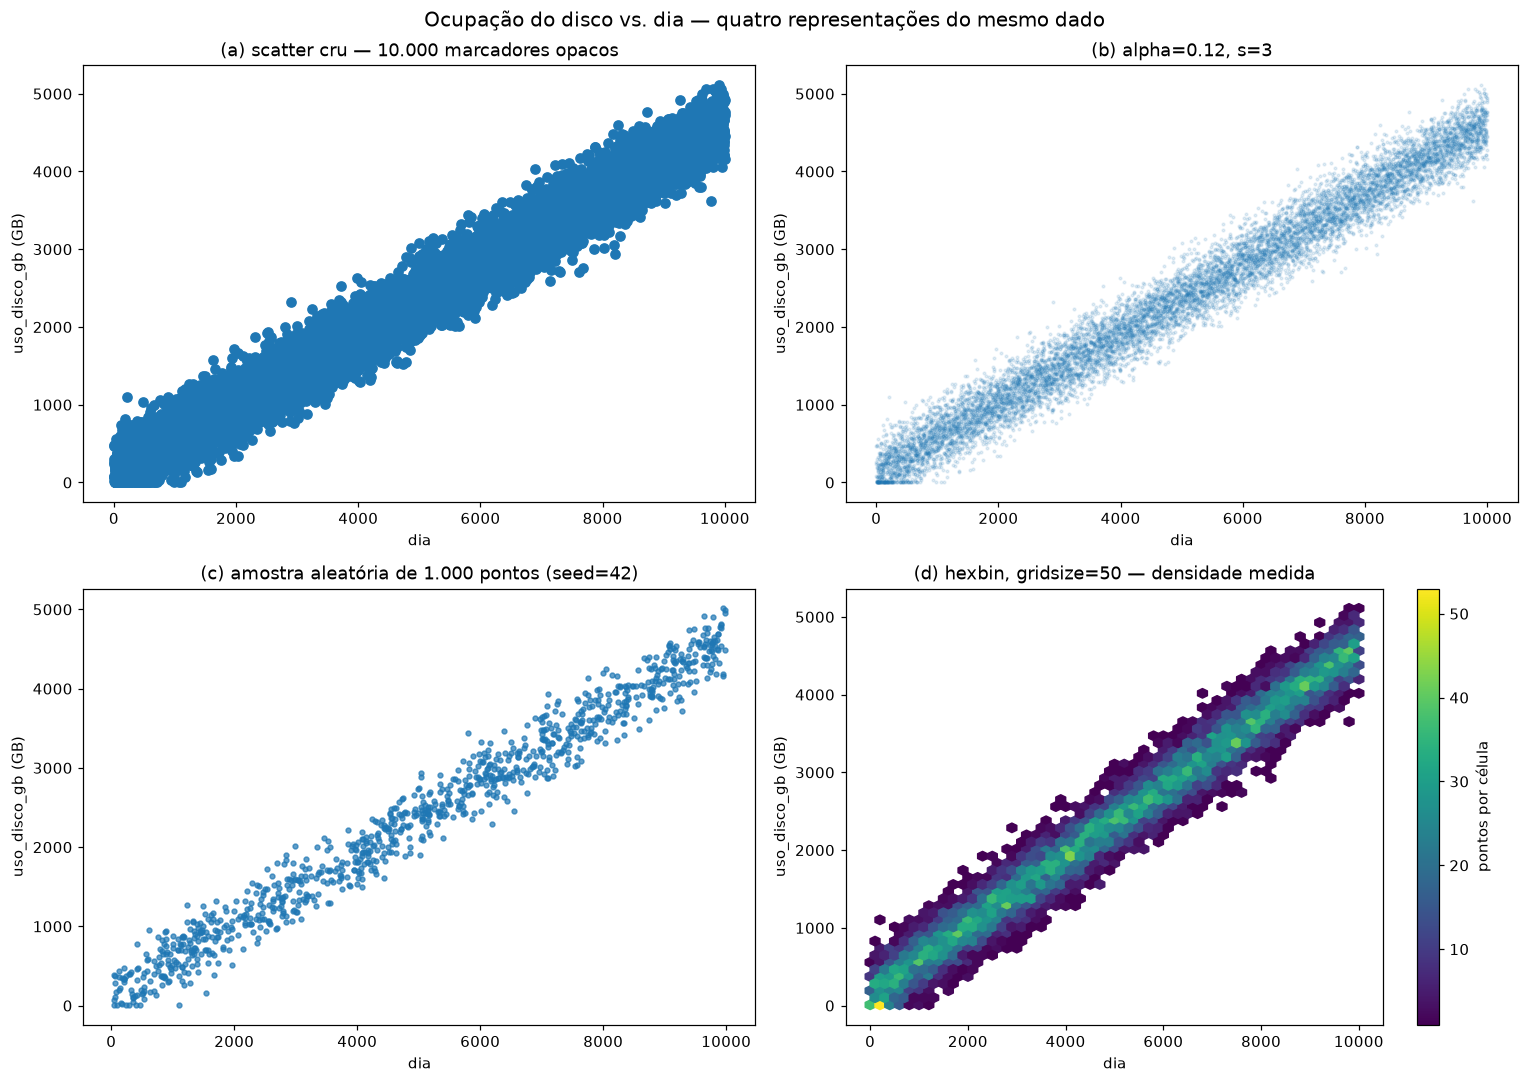

In [8]:
x = df["dia"].values
y = df["uso_disco_gb"].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Ocupação do disco vs. dia — quatro representações do mesmo dado", fontsize=13)

# (a) ingênuo -----------------------------------------------------------------
ax = axes[0, 0]
ax.scatter(x, y)
ax.set_title("(a) scatter cru — 10.000 marcadores opacos")

# (b) transparência + marcador pequeno ----------------------------------------
# A opacidade ACUMULA onde há sobreposição: a densidade vira gradiente de cor.
ax = axes[0, 1]
ax.scatter(x, y, s=3, alpha=0.12)
ax.set_title("(b) alpha=0.12, s=3")

# (c) amostragem aleatória -----------------------------------------------------
# replace=False: sem reposição, para não repetir o mesmo dia.
# Parâmetros ajustados à estratégia: com 1.000 pontos, o objetivo é que cada um
# seja visível — manter alpha baixo desfaria o ganho da amostragem.
idx = rng.choice(len(df), size=1000, replace=False)
ax = axes[1, 0]
ax.scatter(x[idx], y[idx], s=10, alpha=0.7)
ax.set_title("(c) amostra aleatória de 1.000 pontos (seed=42)")

# (d) densidade explícita ------------------------------------------------------
# hexbin conta pontos por célula: a densidade deixa de ser sugerida e passa a
# ser MEDIDA, com unidade na barra de cor.
ax = axes[1, 1]
hb = ax.hexbin(x, y, gridsize=50, cmap="viridis", mincnt=1)
fig.colorbar(hb, ax=ax, label="pontos por célula")
ax.set_title("(d) hexbin, gridsize=50 — densidade medida")

for ax in axes.flat:
    ax.set_xlabel("dia")
    ax.set_ylabel("uso_disco_gb (GB)")

fig.tight_layout()
plt.show()

### Comparação das quatro opções

| Opção | Mostra bem | Esconde | Adequada para |
|---|---|---|---|
| **(a)** cru | nada com clareza | densidade, espessura da faixa | demonstrar o problema |
| **(b)** `alpha` baixo | tendência, espessura real, **o piso em 10 GB** | pontos isolados (*outliers*) | **uso geral — escolhida** |
| **(c)** amostragem | tendência, legibilidade individual | eventos raros e estruturas pouco frequentes | datasets muito grandes |
| **(d)** *hexbin* | densidade quantificada | o ponto individual | análise de concentração |

**Escolha para o relatório: (b).**

Justificativa: os 101 pontos censurados representam **1% da amostra**. Numa amostragem de 1.000
pontos, restariam cerca de 10 — a opção **(c) apagaria a descoberta do piso**. Amostragem
aleatória é boa para tendência e ruim para o que é raro ou estrutural. Além disso, com 10× menos
pontos as bordas da nuvem ficam ralas e a variabilidade **parece menor do que é**, o que
trabalha contra a conclusão da Etapa 3.

A opção (d) é apresentada em conjunto por quantificar a concentração — note a célula isolada de
alta contagem no canto inferior esquerdo, que é a assinatura da censura.

## 1.3 Descrição do comportamento observado

1. **A tendência é linear.** O crescimento é visualmente constante ao longo dos 10.000 dias, sem
   curvatura, aceleração ou desaceleração aparentes. A hipótese de linearidade será testada
   formalmente na Etapa 3 (resíduos) e contra um modelo polinomial.

2. **Há ruído substancial em torno da tendência.** A faixa tem espessura da ordem de algumas
   centenas de GB — visível no painel (b) e quantificada na Etapa 3 pelo RMSE.

3. **O ruído é aproximadamente constante ao longo do tempo (homocedástico)**, com **uma
   exceção**: na faixa inicial (até o dia ~1.100) a nuvem é *truncada por baixo* pelo piso de
   10 GB. Não é heterocedasticidade — é **censura**, e o tratamento é diferente.

Essa terceira leitura é a que sustenta a Etapa 4: se a dispersão é estável, o desvio dos
resíduos medido no passado pode ser projetado para o futuro.

---
# Etapa 2 — Ajuste do Modelo Estatístico

## 2.1 Dedução do método dos mínimos quadrados

Modelo postulado:

$$\hat{y} = \beta_0 + \beta_1 x$$

Define-se o erro acumulado como a soma dos quadrados dos desvios:

$$E(\beta_0, \beta_1) = \sum_{i=1}^{n} \bigl(y_i - (\beta_0 + \beta_1 x_i)\bigr)^2$$

Geometricamente, $E$ é um **paraboloide** ("bacia") no espaço $(\beta_0, \beta_1, E)$; o fundo da
bacia é o erro mínimo. Como a função é convexa e diferenciável, o mínimo está onde ambas as
derivadas parciais se anulam. Derivando pela regra da cadeia ($u^2 \to 2u \cdot u'$):

$$\frac{\partial E}{\partial \beta_0} = -2\sum \bigl(y_i - \beta_0 - \beta_1 x_i\bigr) = 0
\qquad
\frac{\partial E}{\partial \beta_1} = -2\sum x_i\bigl(y_i - \beta_0 - \beta_1 x_i\bigr) = 0$$

Essas são as **equações normais**. Elas já contêm dois fatos que serão usados adiante:
$\sum e_i = 0$ e $\sum x_i e_i = 0$, onde $e_i = y_i - \hat{y}_i$. Resolvendo o sistema:

$$\hat{\beta}_1 = \frac{n\sum x_iy_i - \sum x_i \sum y_i}{n \sum x_i^2 - \left(\sum x_i\right)^2}
= \frac{S_{xy}}{S_{xx}},
\qquad
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

com $S_{xy} = \sum (x_i - \bar x)(y_i - \bar y)$ e $S_{xx} = \sum (x_i - \bar x)^2$.

Duas leituras importantes:

- $\hat\beta_1 = S_{xy}/S_{xx}$ é **covariância dividida pela variância de $x$**.
- $\hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$ implica que **a reta passa obrigatoriamente
  pelo ponto $(\bar{x}, \bar{y})$**, o centro de massa dos dados. É um teorema, e será usado
  como teste de sanidade independente.

In [9]:
# --- Estimativa grosseira ANTES do ajuste (teste de ordem de grandeza) -------
# Reta por dois pontos: média de y no início vs. no fim da série.
# Serve para detectar erro de sinal ou de ordem de grandeza no ajuste.
bloco_ini = df.iloc[:500]
bloco_fim = df.iloc[-500:]
delta_y = bloco_fim["uso_disco_gb"].mean() - bloco_ini["uso_disco_gb"].mean()
delta_x = bloco_fim["dia"].mean() - bloco_ini["dia"].mean()
beta1_grosseiro = delta_y / delta_x

print(f"estimativa grosseira de β₁ ≈ {beta1_grosseiro:.4f} GB/dia")

estimativa grosseira de β₁ ≈ 0.4474 GB/dia


In [10]:
# --- Caminho 1: implementação manual (NumPy vetorizado) ----------------------
x_barra = x.mean()
y_barra = y.mean()

Sxy = np.sum((x - x_barra) * (y - y_barra))
Sxx = np.sum((x - x_barra) ** 2)

beta1_mao = Sxy / Sxx
beta0_mao = y_barra - beta1_mao * x_barra

# --- Caminho 2: scikit-learn -------------------------------------------------
# sklearn exige X bidimensional: (n_amostras, n_features).
X = x.reshape(-1, 1)
modelo = LinearRegression().fit(X, y)
beta1_sk = modelo.coef_[0]
beta0_sk = modelo.intercept_

comparacao = pd.DataFrame({
    "Manual (NumPy)":  [beta0_mao, beta1_mao],
    "scikit-learn":    [beta0_sk, beta1_sk],
    "Diferença abs.":  [abs(beta0_mao - beta0_sk), abs(beta1_mao - beta1_sk)],
}, index=["β̂₀ (intercepto)", "β̂₁ (inclinação)"])

display(comparacao)
print(f"\nEquação ajustada:  ŷ = {beta0_mao:.4f} + {beta1_mao:.6f}·x")

,Manual (NumPy),scikit-learn,Diferença abs.
β̂₀ (intercepto),127.6533,127.6533,0.0000
β̂₁ (inclinação),0.4486,0.4486,0.0000



Equação ajustada:  ŷ = 127.6533 + 0.448590·x


In [11]:
# --- Testes de sanidade -------------------------------------------------------

# CHECKPOINT 2 — os dois caminhos devem coincidir até a precisão de máquina.
assert np.isclose(beta1_mao, beta1_sk) and np.isclose(beta0_mao, beta0_sk)
print("CHECKPOINT 2 OK — implementação manual == scikit-learn")

# CHECKPOINT 3 — a reta passa pelo centro de massa (β̂₀ + β̂₁·x̄ = ȳ).
# Teste INDEPENDENTE: não depende de a sklearn concordar com a implementação.
assert np.isclose(beta0_mao + beta1_mao * x_barra, y_barra)
print(f"CHECKPOINT 3 OK — a reta passa por (x̄, ȳ) = ({x_barra:.1f}, {y_barra:.2f})")

# CHECKPOINT 4 — mesma ordem de grandeza da estimativa grosseira.
razao = beta1_mao / beta1_grosseiro
assert 0.5 < razao < 2.0
print(f"CHECKPOINT 4 OK — β̂₁/estimativa grosseira = {razao:.3f} (esperado ≈ 1)")

CHECKPOINT 2 OK — implementação manual == scikit-learn
CHECKPOINT 3 OK — a reta passa por (x̄, ȳ) = (5000.5, 2370.83)
CHECKPOINT 4 OK — β̂₁/estimativa grosseira = 1.003 (esperado ≈ 1)


## 2.3 Interpretação operacional dos coeficientes

In [12]:
print(f"β̂₁ = {beta1_mao:.6f} GB/dia")
print(f"      ≈ {beta1_mao * 30:.2f} GB/mês")
print(f"      ≈ {beta1_mao * 365:.2f} GB/ano")
print(f"\nβ̂₀ = {beta0_mao:.2f} GB  (ocupação prevista no dia 0)")
print(f"\nPara comparação: ocupação prevista no dia 1  = {beta0_mao + beta1_mao:.2f} GB")
print(f"                 ocupação observada no dia 1  = {y[0]:.2f} GB")

β̂₁ = 0.448590 GB/dia
      ≈ 13.46 GB/mês
      ≈ 163.74 GB/ano

β̂₀ = 127.65 GB  (ocupação prevista no dia 0)

Para comparação: ocupação prevista no dia 1  = 128.10 GB
                 ocupação observada no dia 1  = 233.93 GB


**$\hat{\beta}_1$ — a taxa de crescimento.** Tem unidade física: **GB por dia**. É a quantidade
média de espaço que o servidor consome a cada dia de operação — resultante de logs, arquivos
temporários e novos registros. É o número que entra diretamente no dimensionamento de compra e
o único que uma política de retenção consegue alterar.

**$\hat{\beta}_0$ — o intercepto.** Formalmente, a ocupação prevista no "dia 0", que não existe
no dataset (a série começa no dia 1). Sua interpretação como "ocupação inicial do disco antes do
monitoramento" é **defensável aqui**, porque o dia 0 está imediatamente adjacente ao intervalo
observado — extrapolação de um único passo. Fosse o dataset iniciado no dia 5.000, o mesmo
número seria um artefato algébrico sem significado físico.

⚠️ **Ressalva:** o valor de $\hat\beta_0$ está contaminado pela censura descrita na Etapa 1. Os
101 valores truncados em 10 GB estão todos no início da série, exatamente onde o intercepto é
determinado. O truncamento **remove massa da cauda inferior** naquela região, empurrando a reta
para cima. A análise de sensibilidade abaixo quantifica o efeito.

In [13]:
# --- Análise de sensibilidade: reajuste excluindo a região censurada ---------
ultimo_dia_censurado = int(df.loc[no_piso, "dia"].max())
sem_censura = df[df["dia"] > ultimo_dia_censurado]

x_sc = sem_censura["dia"].values
y_sc = sem_censura["uso_disco_gb"].values
mod_sc = LinearRegression().fit(x_sc.reshape(-1, 1), y_sc)

sens = pd.DataFrame({
    "β̂₀ (GB)":      [beta0_mao, mod_sc.intercept_],
    "β̂₁ (GB/dia)":  [beta1_mao, mod_sc.coef_[0]],
    "n":             [len(df), len(sem_censura)],
}, index=["Amostra completa", f"Excluindo dias ≤ {ultimo_dia_censurado}"])

display(sens.round(4))

var_b1 = 100 * (mod_sc.coef_[0] - beta1_mao) / beta1_mao
print(f"\nVariação em β̂₁ ao excluir a região censurada: {var_b1:+.2f}%")
print("Efeito pequeno → o modelo completo é mantido, com a ressalva documentada.")

,β̂₀ (GB),β̂₁ (GB/dia),n
Amostra completa,127.6533,0.4486,10000
Excluindo dias ≤ 1102,121.2491,0.4495,8898



Variação em β̂₁ ao excluir a região censurada: +0.21%
Efeito pequeno → o modelo completo é mantido, com a ressalva documentada.


---
# Etapa 3 — Avaliação do Ajuste e Resíduos

## 3.1 A decomposição da variância

Com $e_i = y_i - \hat{y}_i$ (resíduo), definem-se três somas de quadrados:

$$\mathrm{SQT} = \sum (y_i - \bar{y})^2 \quad\text{(total)} \qquad
\mathrm{SQR} = \sum (\hat{y}_i - \bar{y})^2 \quad\text{(explicada)} \qquad
\mathrm{SQE} = \sum (y_i - \hat{y}_i)^2 \quad\text{(residual)}$$

Vale a identidade $\mathrm{SQT} = \mathrm{SQR} + \mathrm{SQE}$. Ela **não é trivial**: escrevendo
$y_i - \bar{y} = (\hat{y}_i - \bar{y}) + (y_i - \hat{y}_i)$ e elevando ao quadrado, surge o termo
cruzado $2\sum(\hat{y}_i - \bar{y})(y_i - \hat{y}_i)$. A identidade só vale porque esse termo é
**exatamente zero**, e ele é zero por consequência das equações normais da Etapa 2
($\sum e_i = 0$ e $\sum x_i e_i = 0$).

> Ou seja: $R^2$ só é interpretável **porque** o ajuste foi feito por mínimos quadrados. Num
> ajuste obtido por outro critério, $R^2$ pode inclusive ser negativo.

Daí:

$$R^2 = \frac{\mathrm{SQR}}{\mathrm{SQT}} = 1 - \frac{\mathrm{SQE}}{\mathrm{SQT}}
\qquad
\mathrm{RMSE} = \sqrt{\frac{\mathrm{SQE}}{n}}
\qquad
s = \sqrt{\frac{\mathrm{SQE}}{n-2}}$$

O divisor $n-2$ de $s$ (erro padrão residual) contabiliza os dois graus de liberdade consumidos
na estimação de $\hat\beta_0$ e $\hat\beta_1$ — mesma lógica do $n-1$ do desvio amostral. Com
$n = 10.000$ a diferença é numericamente irrelevante, mas $s$ é a quantidade formalmente correta
nas fórmulas da Etapa 4.

In [14]:
y_hat = beta0_mao + beta1_mao * x
residuos = y - y_hat

SQT = np.sum((y - y_barra) ** 2)
SQR = np.sum((y_hat - y_barra) ** 2)
SQE = np.sum(residuos ** 2)

R2 = 1 - SQE / SQT
RMSE = np.sqrt(SQE / n)
s_residual = np.sqrt(SQE / (n - 2))
MAE = np.mean(np.abs(residuos))

print(f"SQT = {SQT:,.0f}")
print(f"SQR = {SQR:,.0f}")
print(f"SQE = {SQE:,.0f}")

# CHECKPOINT 5 — a identidade e as equações normais.
assert np.isclose(SQT, SQR + SQE, rtol=1e-9)
assert np.isclose(np.sum(residuos), 0, atol=1e-6)
assert np.isclose(np.sum(x * residuos), 0, atol=1e-3)
print(f"\nCHECKPOINT 5 OK — SQT = SQR + SQE (erro relativo {abs(SQT-SQR-SQE)/SQT:.2e})")
print(f"                  Σeᵢ = {np.sum(residuos):.2e} ≈ 0")

print(f"\nR²    = {R2:.6f}")
print(f"RMSE  = {RMSE:.2f} GB")
print(f"s     = {s_residual:.2f} GB   (divisor n-2)")
print(f"MAE   = {MAE:.2f} GB")

SQT = 17,288,003,210
SQR = 16,769,407,574
SQE = 518,595,636

CHECKPOINT 5 OK — SQT = SQR + SQE (erro relativo 2.62e-16)
                  Σeᵢ = 1.02e-09 ≈ 0

R²    = 0.970003
RMSE  = 227.73 GB
s     = 227.75 GB   (divisor n-2)
MAE   = 181.55 GB


In [15]:
# CHECKPOINT 6 — em regressão SIMPLES, R² é o coeficiente de correlação ao quadrado.
r_pearson = np.corrcoef(x, y)[0, 1]
assert np.isclose(r_pearson**2, R2)
print(f"r de Pearson = {r_pearson:.6f}")
print(f"r²           = {r_pearson**2:.6f}")
print(f"R²           = {R2:.6f}")
print("\nCHECKPOINT 6 OK — R² = r² (identidade válida apenas com UMA variável explicativa).")

# Conferência cruzada com as métricas da sklearn.
assert np.isclose(R2, r2_score(y, y_hat))
assert np.isclose(RMSE, np.sqrt(mean_squared_error(y, y_hat)))
print("Valores idênticos aos de sklearn.metrics.")

r de Pearson = 0.984887
r²           = 0.970003
R²           = 0.970003

CHECKPOINT 6 OK — R² = r² (identidade válida apenas com UMA variável explicativa).
Valores idênticos aos de sklearn.metrics.


## 3.2 Interpretação: $R^2$ alto **e** erro grande, simultaneamente

Os dois resultados parecem contraditórios e não são:

- $R^2 \approx 0{,}97$ → o modelo explica ~97% da variância de $y$.
- $\mathrm{RMSE} \approx 228$ GB → o desvio típico de uma leitura diária em relação à reta.

A conciliação está no **denominador**. $R^2$ é uma **razão adimensional** que compara o erro do
modelo contra o erro de um modelo trivial que prevê sempre $\bar{y}$:

$$1 - R^2 = \frac{\mathrm{SQE}}{\mathrm{SQT}}$$

Num dataset em que $y$ cresce de ~10 GB a ~5.100 GB, $\mathrm{SQT}$ é **enorme** — porque o
modelo trivial erra absurdamente nas pontas. Uma fração pequena de um número enorme continua
sendo um número grande em valor absoluto.

In [16]:
# Quantificação explícita da comparação implícita no R².
erro_trivial = np.sqrt(np.mean((y - y_barra) ** 2))   # modelo "chuta sempre ȳ"

tabela_metricas = pd.DataFrame({
    "Métrica": ["R²", "RMSE (GB)", "MAE (GB)", "s = √(SQE/(n-2)) (GB)"],
    "Modelo trivial (ŷ = ȳ)": [0.0, erro_trivial, np.mean(np.abs(y - y_barra)), np.nan],
    "Regressão linear": [R2, RMSE, MAE, s_residual],
})
display(tabela_metricas.set_index("Métrica").round(2))

print(f"O modelo reduz o erro típico de {erro_trivial:.0f} GB para {RMSE:.0f} GB "
      f"({100*(1-RMSE/erro_trivial):.1f}% de redução).")
print(f"É isso que o R² de {R2:.4f} está medindo.")

,Modelo trivial (ŷ = ȳ),Regressão linear
Métrica,,
R²,0.0000,0.9700
RMSE (GB),"1,314.8400",227.7300
MAE (GB),"1,133.0100",181.5500
s = √(SQE/(n-2)) (GB),NaN,227.7500


O modelo reduz o erro típico de 1315 GB para 228 GB (82.7% de redução).
É isso que o R² de 0.9700 está medindo.


### Resposta à pergunta 3.2 do enunciado

> *"O que a porcentagem complementar do $R^2$ restante da variância representa no dia a dia da
> infraestrutura de TI?"*

Primeiro, o que ela **não** é: $1 - R^2 \approx 3\%$ **não** é "3% de chance de o modelo errar",
nem "margem de erro de 3%". É a fração da **variância** de $y$ que a reta não reproduz —
uma grandeza adimensional, não uma probabilidade.

A tradução operacional correta é dada pelo **RMSE, em GB**: a ocupação medida num dia qualquer
se afasta da tendência em tipicamente **± 228 GB**. Essa é a flutuação diária irredutível do
servidor — picos de log, jobs de carga, retenção temporária, expurgos — que o modelo, por
construção, não tenta explicar, pois depende apenas do dia.

Para a equipe de infraestrutura, a consequência prática é direta: **nenhuma decisão de capacidade
deve ser tomada sobre a tendência sozinha.** Há uma banda de ± algumas centenas de GB em torno
dela, e é a borda superior dessa banda — não seu centro — que provoca indisponibilidade. Esse
raciocínio é formalizado na Etapa 4.

> Vale o paralelo metodológico: a métrica que orienta decisão é a que tem **unidade do negócio**.
> $R^2$ serve para comparar modelos; RMSE (GB) serve para dimensionar disco.

## 3.3 Análise de resíduos

O enunciado nomeia esta etapa como "Avaliação do Ajuste **e Resíduos**" mas solicita apenas $R^2$
e RMSE. A análise gráfica dos resíduos é o que efetivamente valida (ou invalida) as hipóteses do
modelo, e é ela que autoriza — ou não — o uso do desvio residual na extrapolação da Etapa 4.

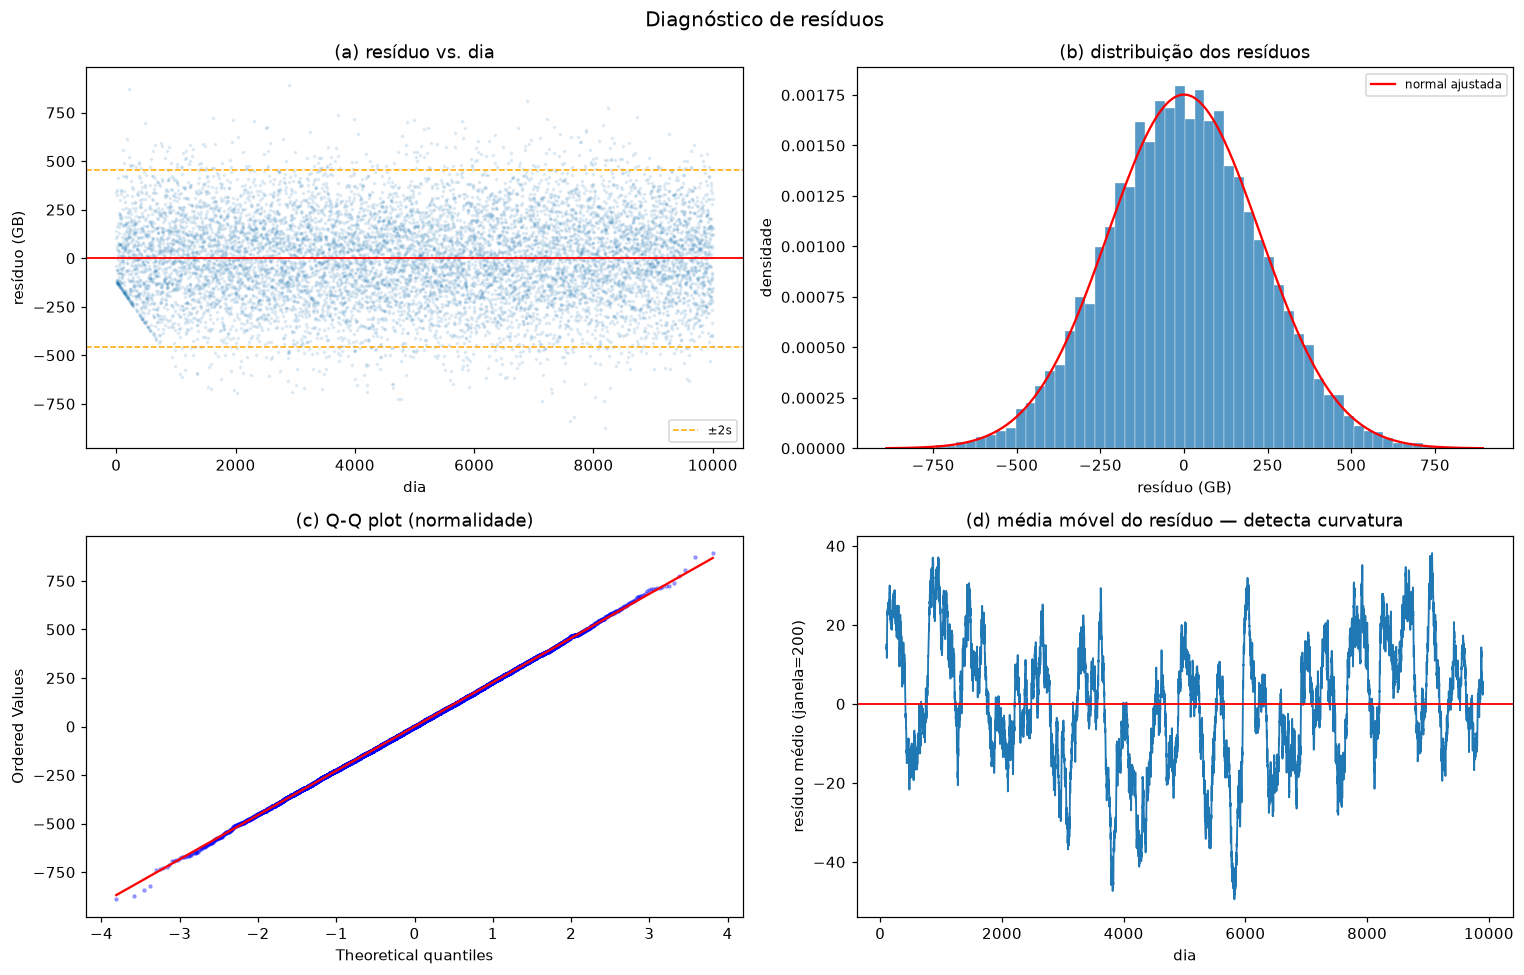

média dos resíduos : 1.02e-13 GB  (zero por construção)
desvio dos resíduos: 227.75 GB
assimetria (skew)  : 0.0193   (0 = simétrica)
curtose (excesso)  : 0.0314   (0 = normal)


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Diagnóstico de resíduos", fontsize=13)

# (a) resíduo vs. dia: procura-se faixa de largura constante centrada em zero.
ax = axes[0, 0]
ax.scatter(x, residuos, s=2, alpha=0.10)
ax.axhline(0, color="red", lw=1.2)
ax.axhline(2 * s_residual, color="orange", lw=1, ls="--", label="±2s")
ax.axhline(-2 * s_residual, color="orange", lw=1, ls="--")
ax.set_xlabel("dia"); ax.set_ylabel("resíduo (GB)")
ax.set_title("(a) resíduo vs. dia")
ax.legend(loc="lower right", fontsize=8)

# (b) histograma: a hipótese de normalidade usada na Etapa 4.
ax = axes[0, 1]
ax.hist(residuos, bins=60, density=True, alpha=0.75, edgecolor="white", linewidth=0.3)
grade = np.linspace(residuos.min(), residuos.max(), 400)
ax.plot(grade, stats.norm.pdf(grade, residuos.mean(), residuos.std()),
        color="red", lw=1.5, label="normal ajustada")
ax.set_xlabel("resíduo (GB)"); ax.set_ylabel("densidade")
ax.set_title("(b) distribuição dos resíduos")
ax.legend(fontsize=8)

# (c) Q-Q plot: normalidade com mais rigor que o histograma, sobretudo nas caudas.
ax = axes[1, 0]
stats.probplot(residuos, dist="norm", plot=ax)
ax.set_title("(c) Q-Q plot (normalidade)")
ax.get_lines()[0].set_markersize(2)
ax.get_lines()[0].set_alpha(0.3)

# (d) média móvel do resíduo: revela curvatura sistemática que o scatter esconde.
janela = 200
media_movel = pd.Series(residuos).rolling(janela, center=True).mean()
ax = axes[1, 1]
ax.plot(x, media_movel, lw=1.2)
ax.axhline(0, color="red", lw=1.2)
ax.set_xlabel("dia"); ax.set_ylabel(f"resíduo médio (janela={janela})")
ax.set_title("(d) média móvel do resíduo — detecta curvatura")

fig.tight_layout()
plt.show()

print(f"média dos resíduos : {residuos.mean():.2e} GB  (zero por construção)")
print(f"desvio dos resíduos: {residuos.std(ddof=2):.2f} GB")
print(f"assimetria (skew)  : {stats.skew(residuos):.4f}   (0 = simétrica)")
print(f"curtose (excesso)  : {stats.kurtosis(residuos):.4f}   (0 = normal)")

### Leitura do diagnóstico

- **(a)** A faixa tem **largura praticamente constante** ao longo dos 10.000 dias e está centrada
  em zero: evidência de **homocedasticidade**. A exceção é inconfundível: a **reta descendente**
  no canto inferior esquerdo (dias 14–1.102). Não é ruído — são os pontos censurados. Para eles
  $y_i = 10$ é constante, logo $e_i = 10 - (\hat\beta_0 + \hat\beta_1 x_i)$ decresce
  **linearmente** com $x$. Censura em $y$ produz uma reta no gráfico de resíduos; essa é sua
  assinatura gráfica.
- **(b) e (c)** Os resíduos são **essencialmente normais**: assimetria $\approx 0{,}019$ e excesso
  de curtose $\approx 0{,}031$ (ambos ~0 na normal), e o Q-Q plot alinha-se à diagonal de ponta a
  ponta, **inclusive nas caudas**. A censura, embora visualmente óbvia em (a), afeta apenas 1% da
  amostra e não distorce perceptivelmente a distribuição agregada — o que justifica usar a
  hipótese de normalidade na Etapa 4.
- **(d)** A média móvel oscila em torno de zero **sem padrão sistemático de curvatura**: não há
  sinal de que a relação seja não-linear. Uma tendência curva apareceria aqui como um arco
  persistente acima ou abaixo do eixo.

**Conclusão:** as hipóteses do modelo linear são satisfeitas na maior parte do domínio. A
violação localizada (censura no início) está longe da região de extrapolação (final da série) e
**não compromete a Etapa 4** — mas fica registrada.

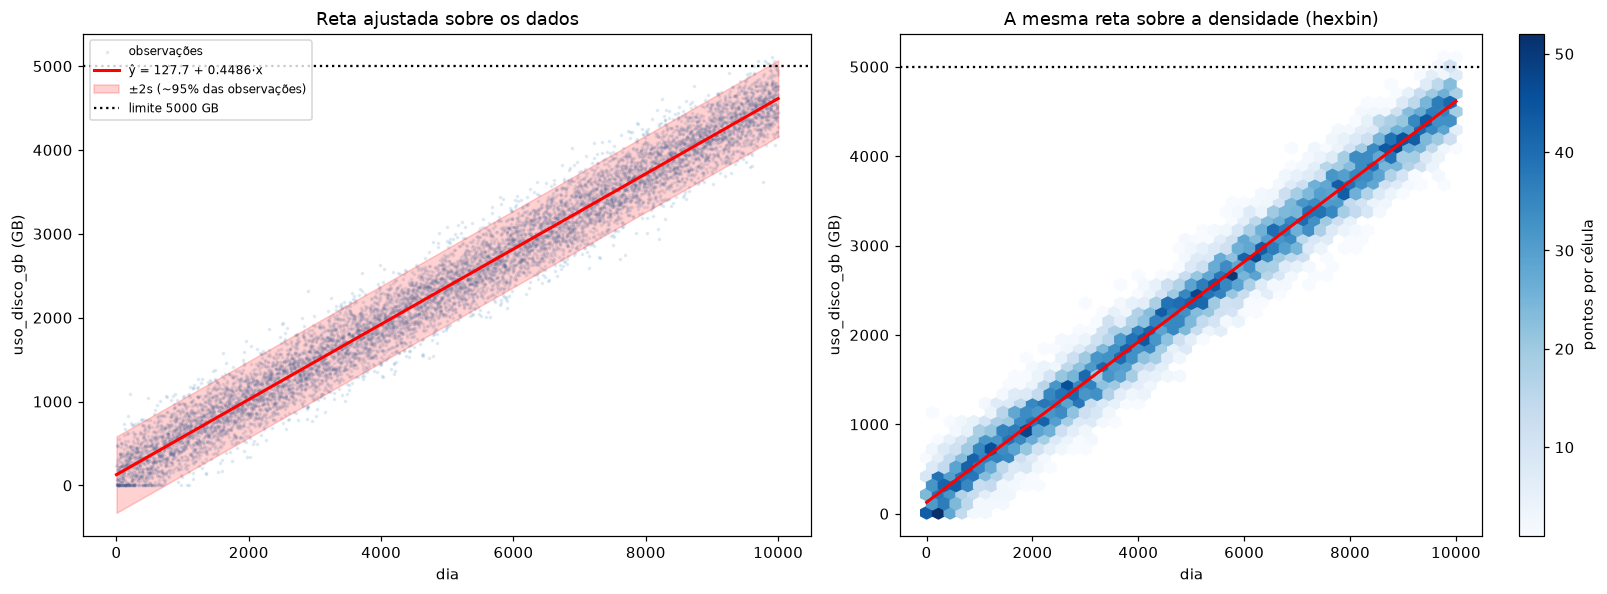

In [18]:
# --- A reta ajustada sobreposta aos dados (item 3.3 do enunciado) ------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Versão 1: dados com transparência + reta + banda de ±2s
ax = axes[0]
ax.scatter(x, y, s=2, alpha=0.10, label="observações")
ax.plot(x, y_hat, color="red", lw=2, label=f"ŷ = {beta0_mao:.1f} + {beta1_mao:.4f}·x")
ax.fill_between(x, y_hat - 2*s_residual, y_hat + 2*s_residual,
                color="red", alpha=0.18, label="±2s (~95% das observações)")
ax.axhline(LIMITE_GB, color="black", ls=":", lw=1.5, label=f"limite {LIMITE_GB} GB")
ax.set_xlabel("dia"); ax.set_ylabel("uso_disco_gb (GB)")
ax.set_title("Reta ajustada sobre os dados")
ax.legend(fontsize=8, loc="upper left")

# Versão 2: hexbin + reta — a mesma reta sobre a densidade medida
ax = axes[1]
hb = ax.hexbin(x, y, gridsize=45, cmap="Blues", mincnt=1)
fig.colorbar(hb, ax=ax, label="pontos por célula")
ax.plot(x, y_hat, color="red", lw=2)
ax.axhline(LIMITE_GB, color="black", ls=":", lw=1.5)
ax.set_xlabel("dia"); ax.set_ylabel("uso_disco_gb (GB)")
ax.set_title("A mesma reta sobre a densidade (hexbin)")

fig.tight_layout()
plt.show()

### Comparação com modelo polinomial

O cronograma do projeto prevê, no bloco de Regressão Linear, a comparação com regressão
polinomial. Se a relação fosse curva, um polinômio de grau 2 ou 3 traria ganho relevante.

Como acrescentar termos **nunca reduz** o $R^2$ (um polinômio de grau maior contém o de grau
menor como caso particular), a comparação honesta usa o **$R^2$ ajustado**, que penaliza
parâmetros adicionais:

$$R^2_{\text{aj}} = 1 - (1 - R^2)\,\frac{n-1}{n-p-1}$$

In [19]:
def r2_ajustado(r2, n_obs, n_params):
    return 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_params - 1)

linhas = []
for grau in (1, 2, 3):
    coefs = np.polyfit(x, y, grau)
    pred = np.polyval(coefs, x)
    r2_g = r2_score(y, pred)
    linhas.append({
        "Grau": grau,
        "Parâmetros": grau + 1,
        "R²": r2_g,
        "R² ajustado": r2_ajustado(r2_g, n, grau),
        "RMSE (GB)": np.sqrt(mean_squared_error(y, pred)),
    })

comp_poli = pd.DataFrame(linhas).set_index("Grau")
display(comp_poli.round(6))

ganho = comp_poli.loc[2, "R² ajustado"] - comp_poli.loc[1, "R² ajustado"]
print(f"\nGanho de R² ajustado ao passar de grau 1 para grau 2: {ganho:+.2e}")
print("Ganho desprezível → o modelo LINEAR é o adequado (princípio da parcimônia).")

,Parâmetros,R²,R² ajustado,RMSE (GB)
Grau,,,,
1,2,0.9700,0.9700,227.7269
2,3,0.9700,0.9700,227.6371
3,4,0.9700,0.9700,227.6252



Ganho de R² ajustado ao passar de grau 1 para grau 2: +2.07e-05
Ganho desprezível → o modelo LINEAR é o adequado (princípio da parcimônia).


---
# Etapa 4 — Predição e Tomada de Decisão Tecnológica

## 4.1 A resposta direta do enunciado

Invertendo a equação ajustada para o limite operacional de 5.000 GB:

$$x^{*} = \frac{5000 - \hat{\beta}_0}{\hat{\beta}_1}$$

In [20]:
x_estrela = (LIMITE_GB - beta0_mao) / beta1_mao
ultimo_dia = int(df["dia"].max())
dias_restantes = x_estrela - ultimo_dia

print(f"Dia em que a TENDÊNCIA atinge {LIMITE_GB} GB:  x* = {x_estrela:,.1f}")
print(f"Último dia monitorado:                        {ultimo_dia:,}")
print(f"Dias restantes (resposta direta):             {dias_restantes:,.0f} dias")
print(f"                                              ≈ {dias_restantes/30:,.1f} meses")
print(f"                                              ≈ {dias_restantes/365:,.1f} anos")

Dia em que a TENDÊNCIA atinge 5000 GB:  x* = 10,861.5
Último dia monitorado:                        10,000
Dias restantes (resposta direta):             861 dias
                                              ≈ 28.7 meses
                                              ≈ 2.4 anos


## 4.2 Por que essa resposta é insuficiente

$x^{*}$ é o dia em que a **média prevista** cruza 5.000 GB. Mas o disco não enche na média: ele
enche num dia concreto, com o ruído daquele dia. E a Etapa 1 já mostrou que **nove dias da
própria amostra ultrapassaram 5.000 GB**, o primeiro no dia 9.628 — muito antes de $x^{*}$.

Formalmente, há duas quantidades distintas, e a diferença entre elas é um único termo "1" sob
a raiz:

$$\textbf{Intervalo de confiança (onde está a MÉDIA de } y \text{ em } x_0):\quad
\hat{y}_0 \pm t_{\alpha/2,\,n-2}\; s \sqrt{\frac{1}{n} + \frac{(x_0 - \bar{x})^2}{S_{xx}}}$$

$$\textbf{Intervalo de predição (onde estará UMA observação em } x_0):\quad
\hat{y}_0 \pm t_{\alpha/2,\,n-2}\; s \sqrt{1 + \frac{1}{n} + \frac{(x_0 - \bar{x})^2}{S_{xx}}}$$

Os três termos sob a raiz têm significados distintos:

| Termo | Significado | Comportamento |
|---|---|---|
| $1$ | variabilidade irredutível de uma observação individual | **não desaparece** nem com $n \to \infty$ |
| $1/n$ | incerteza sobre a posição da média | desprezível aqui ($n = 10^4$) |
| $\dfrac{(x_0-\bar{x})^2}{S_{xx}}$ | **penalidade da extrapolação** | cresce com o *quadrado* da distância a $\bar{x}$ |

Para infraestrutura, o que importa é o **intervalo de predição**: a pergunta não é "quando a
ocupação média chega a 5.000 GB", e sim "a partir de quando há risco relevante de um dia
qualquer estourar 5.000 GB".

In [21]:
# Retorna (ŷ, erro do IC da média, erro do IP de uma observação) em x0.
def intervalos(x0, confianca=0.95):
    x0 = np.asarray(x0, dtype=float)
    y0 = beta0_mao + beta1_mao * x0
    t_crit = stats.t.ppf(1 - (1 - confianca) / 2, df=n - 2)
    nucleo = 1.0 / n + (x0 - x_barra) ** 2 / Sxx
    return y0, t_crit * s_residual * np.sqrt(nucleo), t_crit * s_residual * np.sqrt(1 + nucleo)


# Decomposição do erro no ponto crítico, para ver o peso de cada termo.
termo_media = 1.0 / n
termo_extrap = (x_estrela - x_barra) ** 2 / Sxx

print(f"Em x₀ = x* = {x_estrela:,.0f}:")
print(f"  termo 1 (observação individual) = 1.000000")
print(f"  termo 1/n                       = {termo_media:.6f}")
print(f"  termo (x₀-x̄)²/Sxx               = {termo_extrap:.6f}")
print(f"\n→ A variabilidade individual domina: representa "
      f"{100/(1+termo_media+termo_extrap):.1f}% do total sob a raiz.")
print("  A penalidade de extrapolação ainda é pequena porque x* está próximo do")
print("  fim da série — extrapolar 861 dias após 10.000 observados é pouco.")

_, ic, ip = intervalos(x_estrela)
print(f"\nEm x*: IC 95% da média = ±{ic:,.2f} GB")
print(f"       IP 95% de um dia = ±{ip:,.2f} GB   ({ip/ic:,.0f}× mais largo)")

Em x₀ = x* = 10,861:
  termo 1 (observação individual) = 1.000000
  termo 1/n                       = 0.000100
  termo (x₀-x̄)²/Sxx               = 0.000412

→ A variabilidade individual domina: representa 99.9% do total sob a raiz.
  A penalidade de extrapolação ainda é pequena porque x* está próximo do
  fim da série — extrapolar 861 dias após 10.000 observados é pouco.

Em x*: IC 95% da média = ±10.10 GB
       IP 95% de um dia = ±446.55 GB   (44× mais largo)


In [22]:
# --- O dia em que o RISCO se torna relevante ---------------------------------
# Procura-se x tal que P(y > 5000 | x) = 5%, ou seja, o percentil 95 da
# distribuição preditiva cruza o limite:
#     β̂₀ + β̂₁·x + z₀.₉₅·s = 5000
z95 = stats.norm.ppf(0.95)          # ≈ 1.645
x_risco = (LIMITE_GB - z95 * s_residual - beta0_mao) / beta1_mao

# Probabilidade de estouro no último dia observado e hoje.
def prob_estouro(x0):
    y0 = beta0_mao + beta1_mao * x0
    return 1 - stats.norm.cdf((LIMITE_GB - y0) / s_residual)

print(f"Dia em que a TENDÊNCIA atinge 5.000 GB          : {x_estrela:,.0f}")
print(f"Dia em que o PERCENTIL 95 atinge 5.000 GB       : {x_risco:,.0f}")
print(f"\nDiferença entre as duas respostas               : "
      f"{x_estrela - x_risco:,.0f} dias")
print(f"\nP(estouro) no último dia observado ({ultimo_dia}) : "
      f"{100*prob_estouro(ultimo_dia):.2f}%")
print(f"Dias de margem real a partir do dia {ultimo_dia}     : "
      f"{x_risco - ultimo_dia:,.0f} dias")

# Validação contra a amostra: a taxa prevista bate com a observada?
ultimos = df[df["dia"] > 9500]
taxa_obs = (ultimos["uso_disco_gb"] > LIMITE_GB).mean()
taxa_prev = np.mean([prob_estouro(d) for d in ultimos["dia"]])
print(f"\nValidação (dias 9.501–10.000):")
print(f"  taxa observada de estouro : {100*taxa_obs:.2f}%")
print(f"  taxa prevista pelo modelo : {100*taxa_prev:.2f}%")

Dia em que a TENDÊNCIA atinge 5.000 GB          : 10,861
Dia em que o PERCENTIL 95 atinge 5.000 GB       : 10,026

Diferença entre as duas respostas               : 835 dias

P(estouro) no último dia observado (10000) : 4.49%
Dias de margem real a partir do dia 10000     : 26 dias

Validação (dias 9.501–10.000):
  taxa observada de estouro : 1.80%
  taxa prevista pelo modelo : 1.76%


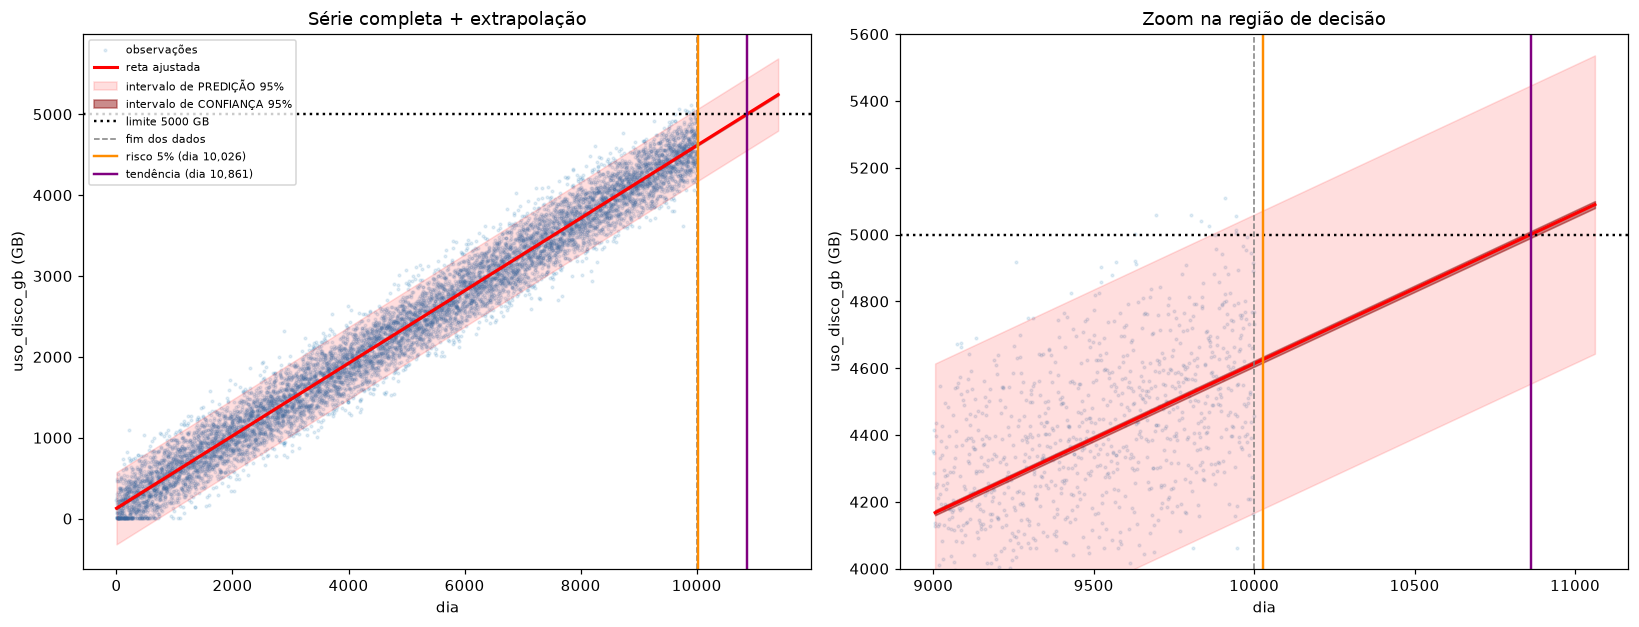

In [23]:
# --- Visualização da extrapolação com as duas bandas -------------------------
x_fut = np.linspace(1, x_estrela * 1.05, 600)
y_fut, erro_ic, erro_ip = intervalos(x_fut)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

for ax, (ini, fim, titulo) in zip(axes, [
    (1, x_estrela * 1.05, "Série completa + extrapolação"),
    (9000, x_estrela * 1.02, "Zoom na região de decisão"),
]):
    visivel = (x_fut >= ini) & (x_fut <= fim)
    obs = (x >= ini) & (x <= fim)

    ax.scatter(x[obs], y[obs], s=3, alpha=0.12, label="observações")
    ax.plot(x_fut[visivel], y_fut[visivel], color="red", lw=2, label="reta ajustada")
    ax.fill_between(x_fut[visivel], (y_fut - erro_ip)[visivel], (y_fut + erro_ip)[visivel],
                    color="red", alpha=0.13, label="intervalo de PREDIÇÃO 95%")
    ax.fill_between(x_fut[visivel], (y_fut - erro_ic)[visivel], (y_fut + erro_ic)[visivel],
                    color="darkred", alpha=0.45, label="intervalo de CONFIANÇA 95%")

    ax.axhline(LIMITE_GB, color="black", ls=":", lw=1.6, label=f"limite {LIMITE_GB} GB")
    ax.axvline(ultimo_dia, color="gray", ls="--", lw=1, label="fim dos dados")
    ax.axvline(x_risco, color="darkorange", lw=1.6, label=f"risco 5% (dia {x_risco:,.0f})")
    ax.axvline(x_estrela, color="purple", lw=1.6, label=f"tendência (dia {x_estrela:,.0f})")

    ax.set_xlabel("dia"); ax.set_ylabel("uso_disco_gb (GB)")
    ax.set_title(titulo)

axes[1].set_ylim(4000, 5600)
axes[0].legend(fontsize=7.5, loc="upper left")
fig.tight_layout()
plt.show()

**O que o gráfico da direita mostra:** a banda escura (intervalo de confiança) é estreitíssima —
a *posição da reta* é conhecida com precisão, graças às 10.000 observações. A banda clara
(intervalo de predição) é largíssima — a *observação de um dia* permanece incerta,
independentemente do tamanho da amostra.

A linha laranja (risco de 5%) cruza o limite **centenas de dias antes** da linha roxa
(tendência). Essa distância é a margem que uma decisão baseada apenas em $x^{*}$ destruiria.

---
## 4.3 Síntese numérica

In [24]:
resumo = pd.DataFrame({
    "Quantidade": [
        "Equação ajustada",
        "Taxa de crescimento",
        "Coeficiente de determinação (R²)",
        "Erro típico diário (RMSE)",
        "Último dia monitorado",
        "Ocupação prevista no último dia",
        "Dia em que a TENDÊNCIA atinge 5.000 GB",
        "Dia em que o RISCO (5%) atinge 5.000 GB",
        "Margem a partir do fim dos dados (tendência)",
        "Margem a partir do fim dos dados (risco)",
        "Dias da amostra já acima de 5.000 GB",
    ],
    "Valor": [
        f"ŷ = {beta0_mao:.2f} + {beta1_mao:.6f}·x",
        f"{beta1_mao:.4f} GB/dia  ({beta1_mao*30:.1f} GB/mês · {beta1_mao*365:.0f} GB/ano)",
        f"{R2:.4f}",
        f"{RMSE:.1f} GB",
        f"{ultimo_dia:,}",
        f"{beta0_mao + beta1_mao*ultimo_dia:,.1f} GB",
        f"{x_estrela:,.0f}",
        f"{x_risco:,.0f}",
        f"{dias_restantes:,.0f} dias (~{dias_restantes/30:.0f} meses)",
        f"{x_risco - ultimo_dia:,.0f} dias",
        f"{int(acima.sum())} (primeiro no dia {int(df.loc[acima,'dia'].min())})",
    ],
}).set_index("Quantidade")

display(resumo)

,Valor
Quantidade,
Equação ajustada,ŷ = 127.65 + 0.448590·x
Taxa de crescimento,0.4486 GB/dia (13.5 GB/mês · 164 GB/ano)
Coeficiente de determinação (R²),0.9700
Erro típico diário (RMSE),227.7 GB
Último dia monitorado,"10,000"
Ocupação prevista no último dia,"4,613.6 GB"
Dia em que a TENDÊNCIA atinge 5.000 GB,"10,861"
Dia em que o RISCO (5%) atinge 5.000 GB,"10,026"
Margem a partir do fim dos dados (tendência),861 dias (~29 meses)


## 4.4 Recomendação técnica à gestão de TI

**Diagnóstico.** O servidor consome aproximadamente **13,5 GB/mês** (≈ 164 GB/ano) de forma
estável e linear ao longo de todo o período monitorado. O ajuste é excelente ($R^2 = 0{,}97$),
mas a ocupação diária flutua em torno da tendência com desvio típico de **±228 GB**.

**O ponto central.** A leitura ingênua do modelo indica cerca de **861 dias** (≈ 28 meses) até o
esgotamento. Essa resposta descreve a *tendência média* e **subestima gravemente o risco
operacional**: considerando a flutuação diária, a probabilidade de um dia qualquer ultrapassar
5.000 GB já é da ordem de **4–5% no dia 10.000** — e, de fato, **nove dias da própria amostra já
excederam o limite**. A margem real até um risco relevante é de **dezenas de dias**, não de anos.

**Plano de ação recomendado:**

| Prazo | Ação |
|---|---|
| **Imediato (0–30 dias)** | Instituir alarme em 4.500 GB (90%) e revisar o limite operacional. O disco já opera na zona de risco: eventos de estouro ocorrem hoje. |
| **Curto (30–90 dias)** | Executar política de retenção/expurgo de logs. É a única medida que reduz $\hat\beta_1$ — as demais apenas adiam o problema. |
| **Médio (90–180 dias)** | Concluir a aquisição de armazenamento, contemplando o *lead time* de compra e janela de manutenção. Dimensionar pelo percentil, não pela média. |
| **Contínuo** | Reajustar o modelo mensalmente. A estimativa de $\hat\beta_1$ é válida enquanto o regime de uso não mudar. |

**Duas intervenções, matematicamente distintas:**

- **Política de retenção** altera $\hat{\beta}_1$ — muda a *inclinação* da reta, adiando o
  cruzamento indefinidamente enquanto a política estiver ativa.
- **Disco maior / migração** altera o *limite* — move a linha horizontal que a reta cruza, sem
  alterar a taxa de consumo.

A primeira é estrutural; a segunda, paliativa. Idealmente, ambas.

## 4.5 Limitações e hipóteses declaradas

1. **Persistência do regime.** A extrapolação supõe que a tendência linear continue válida após o
   dia 10.000. O modelo desconhece mudanças de arquitetura, novos serviços, *deploys* ou
   alterações de política de log. É **hipótese**, não resultado.
2. **Censura nos dados.** Os 101 registros truncados em 10 GB (dias 14–1.102) violam localmente a
   hipótese de erros simétricos. A análise de sensibilidade da Etapa 2 mostrou impacto
   desprezível em $\hat\beta_1$; a região afetada é oposta à de extrapolação.
3. **Normalidade dos resíduos.** Os intervalos de predição pressupõem erros normais — hipótese
   sustentada pelo histograma, pelo Q-Q plot e pelos valores de assimetria e curtose, todos
   próximos de zero.
4. **Independência temporal.** O modelo trata cada dia como observação independente. Séries de
   monitoramento frequentemente exibem autocorrelação; um teste de Durbin-Watson e/ou um modelo
   de séries temporais seria o próximo passo natural.
5. **Granularidade diária.** Picos intradiários não são capturados — o disco pode atingir o
   limite em um horário de pico sem que a medição diária registre.

---
# Resumo dos testes de validação

Todos os testes executados neste notebook, na ordem em que aparecem:

| # | Etapa | Verificação | Papel |
|---|---|---|---|
| 0 | 1 | integridade: dimensões, nulos, `dia` = 1..n | valida a premissa do modelo |
| 1 | 1 | $\sigma_{dia}$ contra $\sqrt{(n^2-1)/12}$ | confirma que `dia` é índice |
| 2 | 2 | manual == `scikit-learn` | valida a implementação |
| 3 | 2 | $\hat\beta_0 + \hat\beta_1\bar{x} = \bar{y}$ | teste **independente** da biblioteca |
| 4 | 2 | ordem de grandeza vs. estimativa por dois pontos | detecta erro grosseiro |
| 5 | 3 | $\mathrm{SQT} = \mathrm{SQR} + \mathrm{SQE}$ e $\sum e_i = 0$ | valida as equações normais |
| 6 | 3 | $R^2 = r^2$ | identidade válida só em regressão simples |
| 7 | 4 | taxa de estouro prevista vs. observada | valida o modelo preditivo |

## Conclusão

O modelo de regressão linear simples é **adequado** a estes dados: a relação é linear, os
resíduos são homocedásticos e aproximadamente normais, e o ajuste polinomial não traz ganho.

A contribuição analítica está menos no ajuste — que é direto — e mais na **distinção entre prever
a média e prever uma observação**. A resposta algébrica do enunciado (861 dias) e a resposta
estatisticamente correta (dezenas de dias de margem real) diferem em **uma ordem de grandeza**, e
apenas a segunda é utilizável para *capacity planning*.